# Imports

In [7]:
import os
import glob
import zipfile
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

warnings.filterwarnings('ignore')

# Reading the Data

In [8]:
# Define the zip file pattern
zip_pattern = "data/experiment_data_P0*.zip"

# Lists to store the parsed data
all_csv_trials = []
all_clicks = []
all_mouse_samples = []
all_demographics = []
raw_json_data = []

# Iterate through all zip files matching the pattern
for zip_path in glob.glob(zip_pattern):
    if os.path.exists(zip_path):
        print(f"Processing {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            # Identify the specific JSON and CSV files inside this zip
            file_names = z.namelist()
            json_filename = next((f for f in file_names if f.endswith('.json')), None)
            csv_filename = next((f for f in file_names if f.endswith('.csv')), None)

            # Read and process the CSV file (trial summary)
            if csv_filename:
                with z.open(csv_filename) as csv_file:
                    df_csv = pd.read_csv(csv_file)
                    all_csv_trials.append(df_csv)

            # Read and process the JSON file
            if json_filename:
                with z.open(json_filename) as json_file:
                    data = json.loads(json_file.read().decode('utf-8'))
                    raw_json_data.append(data)

                    p_code = data.get('participant_code', 'Unknown')

                    # Extract Demographics
                    demo = data.get('demographics', {})
                    # Add the participant code so we can merge it later
                    demo['participant_code'] = p_code
                    all_demographics.append(demo)

                    # Flatten click_events
                    if 'click_events' in data:
                        for click in data['click_events']:
                            click['participant_code'] = p_code
                            all_clicks.append(click)

                    # Flatten mouse_samples
                    if 'mouse_samples' in data:
                        for sample in data['mouse_samples']:
                            sample['participant_code'] = p_code
                            all_mouse_samples.append(sample)

print(f"Successfully processed {len(raw_json_data)} participant zip files.")

Processing data\experiment_data_P001.zip...
Processing data\experiment_data_P002.zip...
Processing data\experiment_data_P003.zip...
Processing data\experiment_data_P004.zip...
Processing data\experiment_data_P005.zip...
Processing data\experiment_data_P006.zip...
Processing data\experiment_data_P007.zip...
Processing data\experiment_data_P008.zip...
Processing data\experiment_data_P009.zip...
Processing data\experiment_data_P010.zip...
Processing data\experiment_data_P011.zip...
Processing data\experiment_data_P012.zip...
Processing data\experiment_data_P013.zip...
Processing data\experiment_data_P014.zip...
Processing data\experiment_data_P015.zip...
Processing data\experiment_data_P016.zip...
Processing data\experiment_data_P017.zip...
Processing data\experiment_data_P018.zip...
Processing data\experiment_data_P019.zip...
Processing data\experiment_data_P020.zip...
Processing data\experiment_data_P021.zip...
Successfully processed 21 participant zip files.


In [9]:
# Combine everything into master pandas DataFrames
if all_csv_trials:
    df_trials = pd.concat(all_csv_trials, ignore_index=True)
else:
    df_trials = pd.DataFrame()

df_clicks = pd.DataFrame(all_clicks)
df_mouse = pd.DataFrame(all_mouse_samples)
df_demographics = pd.DataFrame(all_demographics)

def convert_df_to_numeric(df):
    for col in df.columns:
        # Attempts to convert to number
        df[col] = pd.to_numeric(df[col], errors='ignore')
    return df

df_trials = convert_df_to_numeric(df_trials)
df_clicks = convert_df_to_numeric(df_clicks)
df_mouse = convert_df_to_numeric(df_mouse)
df_demographics = convert_df_to_numeric(df_demographics)

print(f"Created df_trials with {len(df_trials)} rows from the CSVs.")
print(f"Created df_clicks with {len(df_clicks)} rows from the JSONs.")
print(f"Created df_mouse with {len(df_mouse)} rows from the JSONs.")
print(f"Created df_demographics with {len(df_demographics)} rows from the JSONs.")

Created df_trials with 252 rows from the CSVs.
Created df_clicks with 1638 rows from the JSONs.
Created df_mouse with 327555 rows from the JSONs.
Created df_demographics with 21 rows from the JSONs.


In [10]:
df_trials.head()

,participant_number,participant_id,participant_code,session_id,assigned_condition,participant_yes_button_side,participant_no_button_side,response_side_assignment_method,presentation_order_method,counterbalance_index,...,total_mouse_distance_confidence1,total_mouse_distance_phase3,total_mouse_distance_confidence2,number_of_pauses_phase1,number_of_pauses_phase3,number_of_direction_changes_phase1,number_of_direction_changes_phase3,dwell_time_yes_button_ms,dwell_time_no_button_ms,dwell_time_confidence_scale_ms
0,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,696,379,561,2,2,0,0,865,0,1449
1,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,519,341,644,4,4,0,0,1486,547,1351
2,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,581,433,927,2,2,0,0,2881,0,1900
3,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,461,478,492,3,3,5,0,602,511,1326
4,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,572,887,679,2,5,0,1,1359,483,2300


In [11]:
df_clicks.head()

,participant_number,participant_id,participant_code,session_id,assigned_condition,trial_index,problem_id,phase,clicked_element,click_timestamp_ms,x,y
0,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,trial_start,start_trial_button,125945,613,399
1,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,yes_button,130033,229,575
2,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,confidence1,confidence_scale,132603,723,395
3,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,center_before_final,center_continue_button,136131,640,392
4,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,final_answer,yes_button,149957,341,546


In [12]:
df_mouse.head()

,participant_number,participant_id,participant_code,session_id,assigned_condition,trial_index,problem_id,phase,timestamp_ms_from_experiment_start,timestamp_ms_from_phase_start,x,y,viewport_width,viewport_height,element_or_zone,countdown_time_remaining_ms,mouse_button_down
0,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,125972,26,613,399,1163,654,problem_text,9974.0,False
1,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,125996,51,613,399,1163,654,problem_text,9950.0,False
2,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,126023,77,613,399,1163,654,problem_text,9923.0,False
3,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,126046,101,613,399,1163,654,problem_text,9899.0,False
4,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,126071,126,613,399,1163,654,problem_text,9874.0,False


In [13]:
df_demographics.head()

,participant_code,age,gender,native_language,english_proficiency,logic_experience,dominant_hand,input_device,vision_status,motor_difficulty
0,P001,22,Woman,Portuguese,5,2,Right,Touchpad,Corrected with glasses/contact lenses,No
1,P002,23,Woman,arabic,4,5,Right,Touchpad,Normal,No
2,P003,26,Man,Hebrew,5,3,Right,Touchpad,Corrected with glasses/contact lenses,No
3,P004,21,Woman,Hebrew,5,4,Right,Touchpad,Normal,No
4,P005,23,Woman,Arabic,5,4,Left,Other,Corrected with glasses/contact lenses,No


In [14]:
# Normalize languages
df_demographics['native_language'] = df_demographics['native_language'].str.lower().str.strip().str.title()
# Replace `heb` with `Hebrew`
df_demographics['native_language'] = df_demographics['native_language'].replace({'Heb': 'Hebrew'})

# Data Exploration

## Demographics

In [15]:
df_trials.groupby(['participant_code','assigned_condition']).first().reset_index()['assigned_condition'].value_counts()

assigned_condition
soft      11
strict    10
Name: count, dtype: int64

In [16]:
participant_conditions = df_trials.groupby(['participant_code','assigned_condition']).first().reset_index()[['participant_code','assigned_condition', 'participant_yes_button_side']]

In [17]:
participant_conditions

,participant_code,assigned_condition,participant_yes_button_side
0,P001,soft,left
1,P002,strict,left
2,P003,soft,right
3,P004,strict,right
4,P005,soft,left
5,P006,soft,right
6,P007,soft,right
7,P008,strict,right
8,P009,soft,left
9,P010,strict,left


In [18]:
# Check for gender distribution in each condition
genders_under_cond = df_demographics.merge(participant_conditions, on='participant_code', how='left').groupby(['assigned_condition', 'gender']).count()
genders_under_cond

participant_code  age  native_language  \
assigned_condition gender                                           
soft               Man                    7    7                7   
                   Woman                  4    4                4   
strict             Man                    4    4                4   
                   Woman                  6    6                6   

                           english_proficiency  logic_experience  \
assigned_condition gender                                          
soft               Man                       7                 7   
                   Woman                     4                 4   
strict             Man                       4                 4   
                   Woman                     6                 6   

                           dominant_hand  input_device  vision_status  \
assigned_condition gender                                               
soft               Man                 7             7              7   
                   Woman               4             4              4   
strict             Man                 4             4              4   
                   Woman               6             6              6   

                           motor_difficulty  participant_yes_button_side  
assigned_condition gender                                                 
soft               Man                    7                            7  
                   Woman                  4                            4  
strict             Man                    4                            4  
                   Woman                  6                            6

In [19]:
def plot_hist(df, column, title, xlabel, ylabel, bins=10, color='skyblue'):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], bins=bins, kde=True, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    print(f"{column}: M={df[column].mean():.2f}, SD={df[column].std():.2f}")

In [20]:
def plot_bar(df, column, title, xlabel, ylabel):
    plt.figure(figsize=(8, 5))
    value_counts = df[column].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values, palette='pastel')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    print(f"{column} value counts:\n{value_counts}")

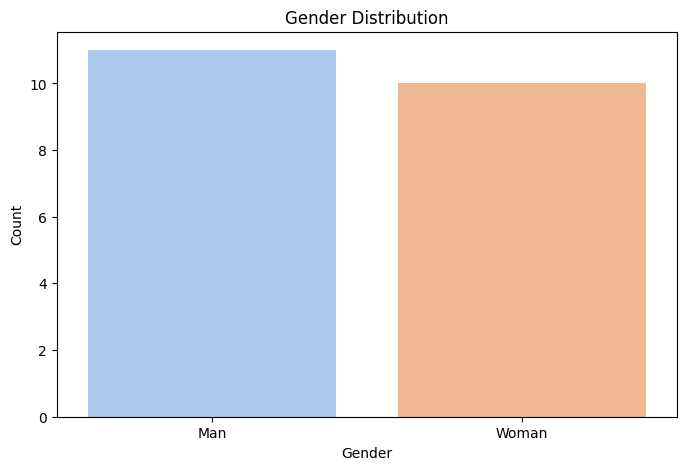

gender value counts:
gender
Man      11
Woman    10
Name: count, dtype: int64


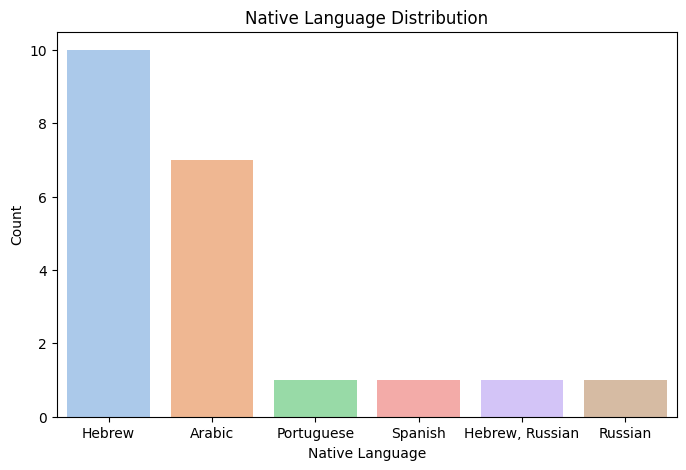

native_language value counts:
native_language
Hebrew             10
Arabic              7
Portuguese          1
Spanish             1
Hebrew, Russian     1
Russian             1
Name: count, dtype: int64


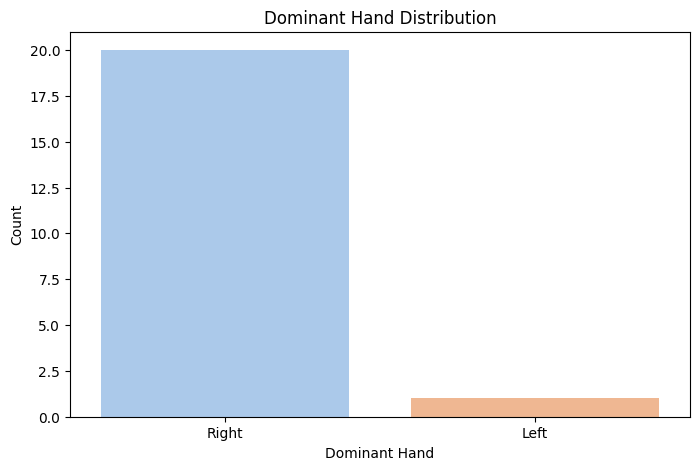

dominant_hand value counts:
dominant_hand
Right    20
Left      1
Name: count, dtype: int64


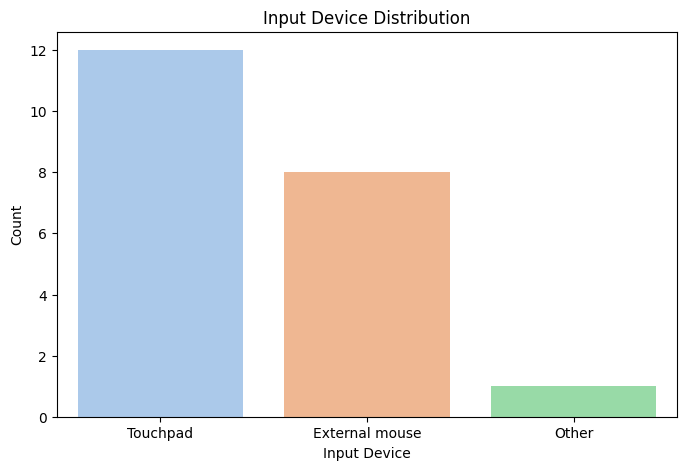

input_device value counts:
input_device
Touchpad          12
External mouse     8
Other              1
Name: count, dtype: int64


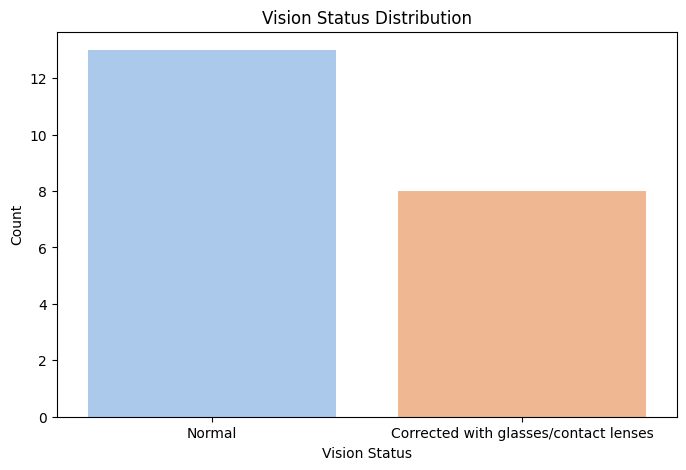

vision_status value counts:
vision_status
Normal                                   13
Corrected with glasses/contact lenses     8
Name: count, dtype: int64


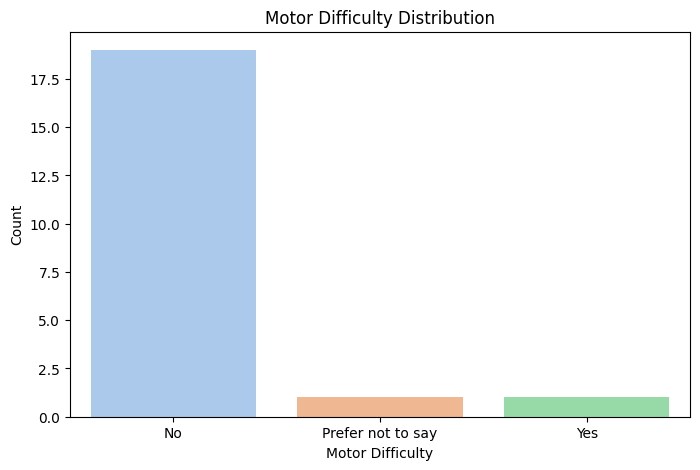

motor_difficulty value counts:
motor_difficulty
No                   19
Prefer not to say     1
Yes                   1
Name: count, dtype: int64


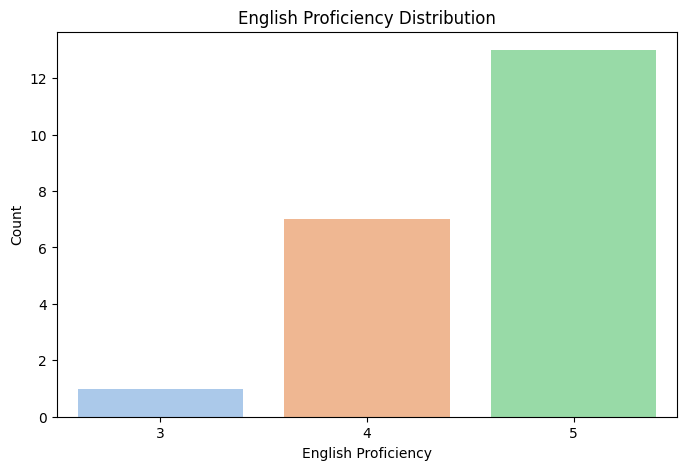

english_proficiency value counts:
english_proficiency
5    13
4     7
3     1
Name: count, dtype: int64


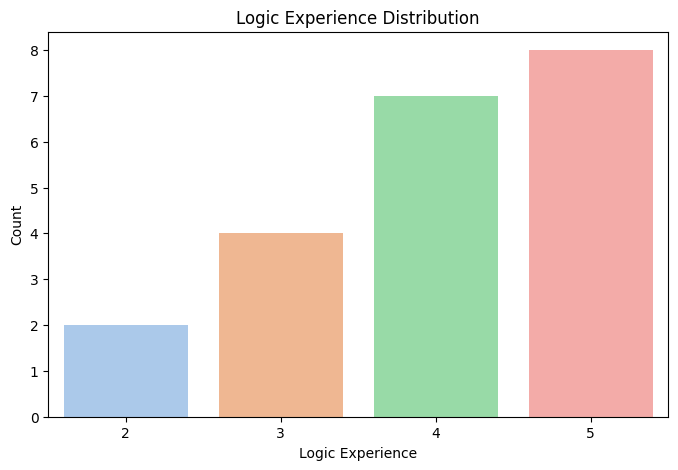

logic_experience value counts:
logic_experience
5    8
4    7
3    4
2    2
Name: count, dtype: int64


In [21]:
bar_cols = ['gender', 'native_language', 'dominant_hand', 'input_device', 'vision_status', 'motor_difficulty', 'english_proficiency', 'logic_experience']
for col in bar_cols:
    plot_bar(df_demographics, col, f'{col.replace("_", " ").title()} Distribution', col.replace("_", " ").title(), 'Count')

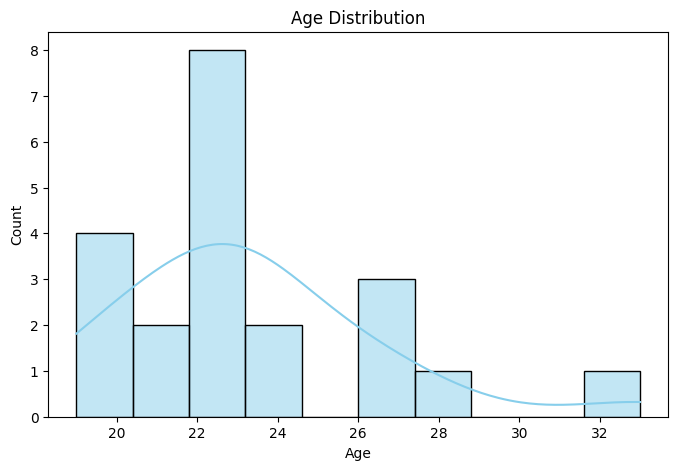

age: M=23.29, SD=3.26


In [22]:
hist_cols = ['age']
for col in hist_cols:
    plot_hist(df_demographics, col, f'{col.replace("_", " ").title()} Distribution', col.replace("_", " ").title(), 'Count')

# Analysis

## Replication

### Acceptance of conclusions

In [23]:
# Create binary columns for acceptance (1 for YES, 0 for NO)
df_trials['accept_phase1'] = df_trials['response1'].map({'YES': 1, 'NO': 0})
df_trials['accept_phase2'] = df_trials['final_response'].map({'YES': 1, 'NO': 0})

# Include 'assigned_condition' in the participant-level aggregation
participant_proportions = df_trials.groupby(
    ['participant_code', 'assigned_condition', 'belief_type', 'validity']
)[['accept_phase1', 'accept_phase2']].mean().reset_index()

# Calculate overall Mean and SE across participants, grouping by condition too
summary = participant_proportions.groupby(['assigned_condition', 'belief_type', 'validity']).agg({
    'accept_phase1': ['mean', 'sem'],
    'accept_phase2': ['mean', 'sem']
})

# Move 'validity' from the rows into the columns
summary = summary.unstack('validity')

# Reorder the column hierarchy to: Response -> Validity -> Metric
summary = summary.reorder_levels([0, 2, 1], axis=1)
summary = summary.sort_index(axis=1, level=[0, 1, 2], ascending=[True, False, True])

summary.rename(columns={'accept_phase1': 'Response 1', 'accept_phase2': 'Response 2'}, level=0, inplace=True)
summary.rename(columns={'valid': 'Valid', 'invalid': 'Invalid'}, level=1, inplace=True)
summary.rename(columns={'mean': 'M', 'sem': 'SE'}, level=2, inplace=True)

# Reindex the Belief Type level and clean presentation across the MultiIndex rows
summary = summary.reindex(['believable', 'unbelievable', 'neutral'], level='belief_type')

# Format row labels
summary.index = summary.index.set_levels(summary.index.levels[0].str.capitalize(), level=0)
summary.index = summary.index.set_levels(summary.index.levels[1].str.capitalize(), level=1)
summary.index.names = ["Condition", "Belief Type"]

print("--- Proportion of Conclusions Accepted Split by Condition ---")
summary.round(3)

--- Proportion of Conclusions Accepted Split by Condition ---


Response 1                       Response 2         \
validity                    Valid        Invalid             Valid          
                                M     SE       M     SE          M     SE   
Condition Belief Type                                                       
Soft      Believable        0.727  0.104   0.591  0.132      0.864  0.070   
          Unbelievable      0.682  0.102   0.409  0.113      0.864  0.070   
          Neutral           0.909  0.061   0.636  0.119      0.955  0.045   
Strict    Believable        0.650  0.130   0.600  0.145      0.850  0.076   
          Unbelievable      0.650  0.130   0.350  0.150      0.900  0.067   
          Neutral           0.700  0.133   0.650  0.150      0.950  0.050   

                                       
validity               Invalid         
                             M     SE  
Condition Belief Type                  
Soft      Believable     0.455  0.125  
          Unbelievable   0.318  0.122  
          Neutral        0.409  0.113  
Strict    Believable     0.500  0.129  
          Unbelievable   0.200  0.111  
          Neutral        0.600  0.145

<table style="border-collapse: collapse; width: 100%; font-family: sans-serif; text-align: right;">
  <caption style="text-align: left; margin-bottom: 8px; font-weight: bold;">
    Table 1: Proportion of conclusions accepted as a function of belief, validity, and response phase.
  </caption>
  <thead>
    <tr style="border-top: 2px solid black;">
      <th rowspan="3" style="text-align: left; vertical-align: bottom; padding: 6px; border-bottom: 1px solid black;">Belief Type</th>
      <th colspan="4" style="text-align: center; padding: 6px;">Response 1</th>
      <th colspan="4" style="text-align: center; padding: 6px;">Response 2</th>
    </tr>
    <tr>
      <th colspan="2" style="text-align: center; padding: 6px;">Valid</th>
      <th colspan="2" style="text-align: center; padding: 6px;">Invalid</th>
      <th colspan="2" style="text-align: center; padding: 6px;">Valid</th>
      <th colspan="2" style="text-align: center; padding: 6px;">Invalid</th>
    </tr>
    <tr style="border-bottom: 1px solid black;">
      <th style="padding: 6px; width: 10%;">M</th>
      <th style="padding: 6px; width: 10%;">SE</th>
      <th style="padding: 6px; width: 10%;">M</th>
      <th style="padding: 6px; width: 10%;">SE</th>
      <th style="padding: 6px; width: 10%;">M</th>
      <th style="padding: 6px; width: 10%;">SE</th>
      <th style="padding: 6px; width: 10%;">M</th>
      <th style="padding: 6px; width: 10%;">SE</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left; padding: 6px;">Believable</td>
      <td style="padding: 6px;">0.690</td>
      <td style="padding: 6px;">0.081</td>
      <td style="padding: 6px;">0.595</td>
      <td style="padding: 6px;">0.095</td>
      <td style="padding: 6px;">0.857</td>
      <td style="padding: 6px;">0.051</td>
      <td style="padding: 6px;">0.476</td>
      <td style="padding: 6px;">0.088</td>
    </tr>
    <tr>
      <td style="text-align: left; padding: 6px;">Unbelievable</td>
      <td style="padding: 6px;">0.667</td>
      <td style="padding: 6px;">0.080</td>
      <td style="padding: 6px;">0.381</td>
      <td style="padding: 6px;">0.091</td>
      <td style="padding: 6px;">0.881</td>
      <td style="padding: 6px;">0.048</td>
      <td style="padding: 6px;">0.262</td>
      <td style="padding: 6px;">0.082</td>
    </tr>
    <tr style="border-bottom: 2px solid black;">
      <td style="text-align: left; padding: 6px;">Neutral</td>
      <td style="padding: 6px;">0.810</td>
      <td style="padding: 6px;">0.073</td>
      <td style="padding: 6px;">0.643</td>
      <td style="padding: 6px;">0.092</td>
      <td style="padding: 6px;">0.952</td>
      <td style="padding: 6px;">0.033</td>
      <td style="padding: 6px;">0.500</td>
      <td style="padding: 6px;">0.091</td>
    </tr>
  </tbody>
</table>

In [24]:
# Create overall acceptance rates per participant, keeping track of their condition
participant_overall_phase1 = df_trials.groupby(['participant_code', 'assigned_condition'])['accept_phase1'].mean().reset_index()
participant_overall_phase2 = df_trials.groupby(['participant_code', 'assigned_condition'])['accept_phase2'].mean().reset_index()

# Run the tests separately for each unique condition in your dataset
for cond in df_trials['assigned_condition'].unique():
    print(f"--- ONE-SAMPLE ACCEPTANCE RATE T-TESTS FOR CONDITION: {cond.upper()} ---")

    # Filter data for the specific condition
    p1_cond_data = participant_overall_phase1[participant_overall_phase1['assigned_condition'] == cond]['accept_phase1'].dropna()
    p2_cond_data = participant_overall_phase2[participant_overall_phase2['assigned_condition'] == cond]['accept_phase2'].dropna()

    # Run one-sample t-tests against chance (0.5)
    t_stat1, p_val1 = stats.ttest_1samp(p1_cond_data, 0.5)
    t_stat2, p_val2 = stats.ttest_1samp(p2_cond_data, 0.5)

    print(f"Phase 1: M = {p1_cond_data.mean():.3f}, t({len(p1_cond_data)-1}) = {t_stat1:.3f}, p = {p_val1:.4f}")
    print(f"Phase 2: M = {p2_cond_data.mean():.3f}, t({len(p2_cond_data)-1}) = {t_stat2:.3f}, p = {p_val2:.4f}")
    print()

--- ONE-SAMPLE ACCEPTANCE RATE T-TESTS FOR CONDITION: SOFT ---
Phase 1: M = 0.659, t(10) = 3.130, p = 0.0107
Phase 2: M = 0.644, t(10) = 2.725, p = 0.0214

--- ONE-SAMPLE ACCEPTANCE RATE T-TESTS FOR CONDITION: STRICT ---
Phase 1: M = 0.592, t(9) = 1.043, p = 0.3240
Phase 2: M = 0.644, t(9) = 2.581, p = 0.0296



For the soft condition, participants appear to have a "yes" bias in both phases. However, for the strict condition, participants were not significantly different from chance in the first phase, perhaps due to the time pressure. In the second phase, participants were significantly above chance, indicating that they were able to correct their initial responses when given more time.

In [25]:
# Check if the participants statistically significantly accepted more answers in the soft condition than in the strict condition for both phases
soft_phase1 = participant_overall_phase1[participant_overall_phase1['assigned_condition'] == 'soft']['accept_phase1'].dropna()
strict_phase1 = participant_overall_phase1[participant_overall_phase1['assigned_condition'] == 'strict']['accept_phase1'].dropna()
soft_phase2 = participant_overall_phase2[participant_overall_phase2['assigned_condition'] == 'soft']['accept_phase2'].dropna()
strict_phase2 = participant_overall_phase2[participant_overall_phase2['assigned_condition'] == 'strict']['accept_phase2'].dropna()

t_soft, p_soft = stats.ttest_ind(soft_phase1, strict_phase1, equal_var=False)
t_strict, p_strict = stats.ttest_ind(soft_phase2, strict_phase2, equal_var=False)

print("--- INDEPENDENT ACCEPTANCE RATE T-TESTS: SOFT VS STRICT CONDITIONS ---")
print(f"Phase 1: Soft Mean = {soft_phase1.mean():.3f}, Strict Mean = {strict_phase1.mean():.3f}, t({len(soft_phase1)+len(strict_phase1)-2}) = {t_soft:.3f}, p = {p_soft:.4f}")
print(f"Phase 2: Soft Mean = {soft_phase2.mean():.3f}, Strict Mean = {strict_phase2.mean():.3f}, t({len(soft_phase2)+len(strict_phase2)-2}) = {t_strict:.3f}, p = {p_strict:.4f}")

--- INDEPENDENT ACCEPTANCE RATE T-TESTS: SOFT VS STRICT CONDITIONS ---
Phase 1: Soft Mean = 0.659, Strict Mean = 0.592, t(19) = 0.662, p = 0.5183
Phase 2: Soft Mean = 0.644, Strict Mean = 0.644, t(19) = -0.005, p = 0.9959


The mean acceptance rate was not different between the soft and strict conditions in both phases.

In [26]:
# Aggregate answer changes per participant, tracking their condition
answer_change_summary = df_trials.groupby(['participant_code', 'assigned_condition'])['answer_changed'].agg(['mean', 'sum', 'count']).reset_index()
answer_change_summary.rename(columns={'mean': 'answer_change_rate', 'sum': 'total_changes', 'count': 'total_questions'}, inplace=True)

# Calculate and print metrics separately for each condition
for cond in df_trials['assigned_condition'].unique():
    cond_summary = answer_change_summary[answer_change_summary['assigned_condition'] == cond]
    mean_rate = cond_summary['answer_change_rate'].mean()

    print(f"--- CONDITION: {cond.upper()} (N = {len(cond_summary)}) ---")
    print(f"{mean_rate * 100:.2f}% average answer change rate across participants.\n")

--- CONDITION: SOFT (N = 11) ---
28.79% average answer change rate across participants.

--- CONDITION: STRICT (N = 10) ---
36.57% average answer change rate across participants.



In [27]:
# Check if the answer change rate was significantly different between the soft and strict conditions

soft_changes = answer_change_summary[answer_change_summary['assigned_condition'] == 'soft']['answer_change_rate'].dropna()
strict_changes = answer_change_summary[answer_change_summary['assigned_condition'] == 'strict']['answer_change_rate'].dropna()

t_change, p_change = stats.ttest_ind(soft_changes, strict_changes, equal_var=False)

print("--- INDEPENDENT ANSWER CHANGE RATE T-TEST: SOFT VS STRICT CONDITIONS ---")
print(f"Soft Mean = {soft_changes.mean():.3f}, Strict Mean = {strict_changes.mean():.3f}, t({len(soft_changes)+len(strict_changes)-2}) = {t_change:.3f}, p = {p_change:.4f}")

--- INDEPENDENT ANSWER CHANGE RATE T-TEST: SOFT VS STRICT CONDITIONS ---
Soft Mean = 0.288, Strict Mean = 0.366, t(19) = -0.971, p = 0.3442


The answer change rate was not significantly different between the soft and strict conditions, suggesting that the time pressure did not affect participants' tendency to change their answers.

In [28]:
# Identify specific directional changes across all trials
df_trials['yes_to_no'] = ((df_trials['response1'] == 'YES') & (df_trials['final_response'] == 'NO')).astype(int)
df_trials['no_to_yes'] = ((df_trials['response1'] == 'NO') & (df_trials['final_response'] == 'YES')).astype(int)

# Aggregate per participant, tracking their experimental condition
change_summary = df_trials.groupby(['participant_code', 'assigned_condition'])[['yes_to_no', 'no_to_yes']].mean().reset_index()

# Run the paired t-test separately for each condition
for cond in change_summary['assigned_condition'].unique():
    cond_data = change_summary[change_summary['assigned_condition'] == cond]

    t_stat, p_val = stats.ttest_rel(cond_data['yes_to_no'], cond_data['no_to_yes'])

    print(f"--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: {cond.upper()} (N = {len(cond_data)}) ---")
    print(f"Mean YES to NO change rate: {cond_data['yes_to_no'].mean():.3f}")
    print(f"Mean NO to YES change rate: {cond_data['no_to_yes'].mean():.3f}")
    print(f"Paired t-test results: t({len(cond_data) - 1}) = {t_stat:.3f}, p = {p_val:.4f}")
    print()

--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: SOFT (N = 11) ---
Mean YES to NO change rate: 0.152
Mean NO to YES change rate: 0.136
Paired t-test results: t(10) = 0.363, p = 0.7244

--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: STRICT (N = 10) ---
Mean YES to NO change rate: 0.142
Mean NO to YES change rate: 0.175
Paired t-test results: t(9) = -0.404, p = 0.6959



Contrary to the paper, there was no significant difference between the rates of changing from YES to NO and NO to YES in each of the two conditions. This suggests that participants were equally likely to switch in either direction.

In [29]:
# Check if the YES to NO and NO to YES change rates were significantly different between the soft and strict conditions

soft_yes_to_no = change_summary[change_summary['assigned_condition'] == 'soft']['yes_to_no'].dropna()
strict_yes_to_no = change_summary[change_summary['assigned_condition'] == 'strict']['yes_to_no'].dropna()
soft_no_to_yes = change_summary[change_summary['assigned_condition'] == 'soft']['no_to_yes'].dropna()
strict_no_to_yes = change_summary[change_summary['assigned_condition'] == 'strict']['no_to_yes'].dropna()

t_soft, p_soft = stats.ttest_ind(soft_yes_to_no, strict_yes_to_no, equal_var=False)
t_strict, p_strict = stats.ttest_ind(soft_no_to_yes, strict_no_to_yes, equal_var=False)

print("--- INDEPENDENT ANSWER CHANGE DIRECTION T-TESTS: SOFT VS STRICT CONDITIONS ---")
print(f"YES to NO: Soft Mean = {soft_yes_to_no.mean():.3f}, Strict Mean = {strict_yes_to_no.mean():.3f}, t({len(soft_yes_to_no)+len(strict_yes_to_no)-2}) = {t_soft:.3f}, p = {p_soft:.4f}")
print(f"NO to YES: Soft Mean = {soft_no_to_yes.mean():.3f}, Strict Mean = {strict_no_to_yes.mean():.3f}, t({len(soft_no_to_yes)+len(strict_no_to_yes)-2}) = {t_strict:.3f}, p = {p_strict:.4f}")

--- INDEPENDENT ANSWER CHANGE DIRECTION T-TESTS: SOFT VS STRICT CONDITIONS ---
YES to NO: Soft Mean = 0.152, Strict Mean = 0.142, t(19) = 0.167, p = 0.8692
NO to YES: Soft Mean = 0.136, Strict Mean = 0.175, t(19) = -0.652, p = 0.5258


The rates of changing from YES to NO and from NO to YES were not significantly different between the soft and strict conditions, suggesting that the time pressure did not affect participants' directional answer change tendencies.

In [30]:
def t_test_answer_change_dir_by_cond(df, belief_type=None, validity=None):
    """
    Perform a paired answer change direction t-test to compare the mean rates
    of changing answers from YES to NO and from NO to YES for each deadline condition.
    """
    for cond in df['assigned_condition'].unique():
        # Subset data by condition, belief, and validity
        subset = df[df['assigned_condition'] == cond]
        if belief_type:
            subset = subset[subset['belief_type'] == belief_type]
        if validity:
            subset = subset[subset['validity'] == validity]

        changes = subset.groupby('participant_code')[['yes_to_no', 'no_to_yes']].mean().reset_index()
        t_stat, p_val = stats.ttest_rel(changes['yes_to_no'], changes['no_to_yes'])

        print(f"--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: {cond.upper()} (N = {len(changes)}) ---")
        print(f"Belief Type: {belief_type if belief_type else 'All'}, Validity: {validity if validity else 'All'}")
        print(f"Mean YES to NO change rate: {changes['yes_to_no'].mean():.3f}")
        print(f"Mean NO to YES change rate: {changes['no_to_yes'].mean():.3f}")
        print(f"Paired t-test results: t({len(changes) - 1}) = {t_stat:.3f}, p = {p_val:.4f}\n")

In [31]:
# Run the split condition tests
t_test_answer_change_dir_by_cond(df_trials, validity='valid')
t_test_answer_change_dir_by_cond(df_trials, validity='invalid')

--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: SOFT (N = 11) ---
Belief Type: All, Validity: valid
Mean YES to NO change rate: 0.061
Mean NO to YES change rate: 0.182
Paired t-test results: t(10) = -2.390, p = 0.0379

--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: STRICT (N = 10) ---
Belief Type: All, Validity: valid
Mean YES to NO change rate: 0.067
Mean NO to YES change rate: 0.233
Paired t-test results: t(9) = -1.936, p = 0.0848

--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: SOFT (N = 11) ---
Belief Type: All, Validity: invalid
Mean YES to NO change rate: 0.242
Mean NO to YES change rate: 0.091
Paired t-test results: t(10) = 1.662, p = 0.1275

--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: STRICT (N = 10) ---
Belief Type: All, Validity: invalid
Mean YES to NO change rate: 0.217
Mean NO to YES change rate: 0.117
Paired t-test results: t(9) = 1.032, p = 0.3288



When conclusions were valid, participants were more likely to change their response to YES than to NO (in a statistically significant way) if they were in the soft condition group. On the other hand, the strict condition group did not have a significant difference. When conclusions were invalid, both conditions did not show a significant difference in answer change rates.

In [32]:
for belief in ['believable', 'unbelievable', 'neutral']:
    for validity in ['valid', 'invalid']:
        t_test_answer_change_dir_by_cond(df_trials, belief_type=belief, validity=validity)

--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: SOFT (N = 11) ---
Belief Type: believable, Validity: valid
Mean YES to NO change rate: 0.045
Mean NO to YES change rate: 0.182
Paired t-test results: t(10) = -1.150, p = 0.2767

--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: STRICT (N = 10) ---
Belief Type: believable, Validity: valid
Mean YES to NO change rate: 0.100
Mean NO to YES change rate: 0.300
Paired t-test results: t(9) = -1.177, p = 0.2695

--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: SOFT (N = 11) ---
Belief Type: believable, Validity: invalid
Mean YES to NO change rate: 0.227
Mean NO to YES change rate: 0.091
Paired t-test results: t(10) = 1.150, p = 0.2767

--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION: STRICT (N = 10) ---
Belief Type: believable, Validity: invalid
Mean YES to NO change rate: 0.200
Mean NO to YES change rate: 0.150
Paired t-test results: t(9) = 0.361, p = 0.7263

--- PAIRED ANSWER CHANGE DIRECTION T-TEST FOR CONDITION:

Contrary to the paper, all problems did not show a significant difference in directional answer change rates, regardless of belief type or validity.

In [33]:
def independent_test_change_rates(df, belief_type=None, validity=None):
    """
    Performs independent-samples t-tests to compare change rates (YES->NO and NO->YES)
    between the strict and soft deadline conditions.
    """
    # Filter by specific subset criteria if provided
    subset = df.copy()
    if belief_type:
        subset = subset[subset['belief_type'] == belief_type]
    if validity:
        subset = subset[subset['validity'] == validity]

    # Aggregate to participant-level means, preserving condition tracking
    changes = subset.groupby(['participant_code', 'assigned_condition'])[['yes_to_no', 'no_to_yes']].mean().reset_index()

    # Split into experimental conditions
    strict_group = changes[changes['assigned_condition'] == 'strict']
    soft_group = changes[changes['assigned_condition'] == 'soft']

    # Context label for printing
    context_str = f"Belief: {belief_type if belief_type else 'All'}, Validity: {validity if validity else 'All'}"

    # 1. Independent T-Test for YES to NO change rate
    t_y2n, p_y2n = stats.ttest_ind(strict_group['yes_to_no'], soft_group['yes_to_no'], equal_var=False)
    print(f"--- INDEPENDENT YES TO NO CHANGE RATE T-TEST BETWEEN CONDITIONS ---")
    print(context_str)
    print(f"Strict Mean: {strict_group['yes_to_no'].mean():.3f} (N={len(strict_group)})")
    print(f"Soft Mean:   {soft_group['yes_to_no'].mean():.3f} (N={len(soft_group)})")
    print(f"t-test results: t = {t_y2n:.3f}, p = {p_y2n:.4f}\n")

    # 2. Independent T-Test for NO to YES change rate
    t_n2y, p_n2y = stats.ttest_ind(strict_group['no_to_yes'], soft_group['no_to_yes'], equal_var=False)
    print(f"--- INDEPENDENT NO TO YES CHANGE RATE T-TEST BETWEEN CONDITIONS ---")
    print(context_str)
    print(f"Strict Mean: {strict_group['no_to_yes'].mean():.3f} (N={len(strict_group)})")
    print(f"Soft Mean:   {soft_group['no_to_yes'].mean():.3f} (N={len(soft_group)})")
    print(f"t-test results: t = {t_n2y:.3f}, p = {p_n2y:.4f}\n")
    print("="*60 + "\n")

In [34]:
# Run independent tests for Valid and Invalid problems overall
independent_test_change_rates(df_trials, validity='valid')
independent_test_change_rates(df_trials, validity='invalid')

--- INDEPENDENT YES TO NO CHANGE RATE T-TEST BETWEEN CONDITIONS ---
Belief: All, Validity: valid
Strict Mean: 0.067 (N=10)
Soft Mean:   0.061 (N=11)
t-test results: t = 0.139, p = 0.8906

--- INDEPENDENT NO TO YES CHANGE RATE T-TEST BETWEEN CONDITIONS ---
Belief: All, Validity: valid
Strict Mean: 0.233 (N=10)
Soft Mean:   0.182 (N=11)
t-test results: t = 0.655, p = 0.5223


--- INDEPENDENT YES TO NO CHANGE RATE T-TEST BETWEEN CONDITIONS ---
Belief: All, Validity: invalid
Strict Mean: 0.217 (N=10)
Soft Mean:   0.242 (N=11)
t-test results: t = -0.255, p = 0.8015

--- INDEPENDENT NO TO YES CHANGE RATE T-TEST BETWEEN CONDITIONS ---
Belief: All, Validity: invalid
Strict Mean: 0.117 (N=10)
Soft Mean:   0.091 (N=11)
t-test results: t = 0.424, p = 0.6772




In [35]:
# Run independent tests for each combination of Validity and Belief Type
for belief in ['believable', 'unbelievable', 'neutral']:
    for validity in ['valid', 'invalid']:
        independent_test_change_rates(df_trials, belief_type=belief, validity=validity)

--- INDEPENDENT YES TO NO CHANGE RATE T-TEST BETWEEN CONDITIONS ---
Belief: believable, Validity: valid
Strict Mean: 0.100 (N=10)
Soft Mean:   0.045 (N=11)
t-test results: t = 0.676, p = 0.5086

--- INDEPENDENT NO TO YES CHANGE RATE T-TEST BETWEEN CONDITIONS ---
Belief: believable, Validity: valid
Strict Mean: 0.300 (N=10)
Soft Mean:   0.182 (N=11)
t-test results: t = 0.705, p = 0.4903


--- INDEPENDENT YES TO NO CHANGE RATE T-TEST BETWEEN CONDITIONS ---
Belief: believable, Validity: invalid
Strict Mean: 0.200 (N=10)
Soft Mean:   0.227 (N=11)
t-test results: t = -0.207, p = 0.8385

--- INDEPENDENT NO TO YES CHANGE RATE T-TEST BETWEEN CONDITIONS ---
Belief: believable, Validity: invalid
Strict Mean: 0.150 (N=10)
Soft Mean:   0.091 (N=11)
t-test results: t = 0.605, p = 0.5531


--- INDEPENDENT YES TO NO CHANGE RATE T-TEST BETWEEN CONDITIONS ---
Belief: unbelievable, Validity: valid
Strict Mean: 0.050 (N=10)
Soft Mean:   0.091 (N=11)
t-test results: t = -0.519, p = 0.6100

--- INDEPENDENT

Between the two conditions, no significant differences were found in the rates of changing answers from YES to NO or from NO to YES, regardless of belief type or validity.

### Response Accuracy

In [46]:
# Helper function to calculate the logic index
def calc_logic_index(group, resp_col):
    valid_accept = group[group['validity'] == 'valid'][resp_col].mean()
    invalid_accept = group[group['validity'] == 'invalid'][resp_col].mean()
    return valid_accept - invalid_accept

In [47]:
# ============================================================
# RESPONSE ACCURACY DATASET FOR PAPER ANOVA
# Logic index = P(accept valid) - P(accept invalid)
# Good/Poor split is done once per participant, not once per belief type
# ============================================================

# 1. Participant-level overall logic index for the Good/Poor split
# We calculate it for both response opportunities, then average them.
overall_logic = df_trials.groupby(['participant_code', 'assigned_condition']).apply(
    lambda x: pd.Series({
        'overall_logic_index_1': calc_logic_index(x, 'accept_phase1'),
        'overall_logic_index_2': calc_logic_index(x, 'accept_phase2')
    })
).reset_index()

overall_logic['overall_logic_index'] = overall_logic[
    ['overall_logic_index_1', 'overall_logic_index_2']
].mean(axis=1)

# 2. Median split separately inside each condition
reasoner_split_dfs = []

for cond in overall_logic['assigned_condition'].unique():
    cond_subset = overall_logic[overall_logic['assigned_condition'] == cond].copy()
    median_logic = cond_subset['overall_logic_index'].median()

    print(f"Condition: {cond.upper()} | Median overall logic index: {median_logic:.3f}")

    cond_subset['reasoner_type'] = np.where(
        cond_subset['overall_logic_index'] >= median_logic,
        'Good',
        'Poor'
    )

    reasoner_split_dfs.append(cond_subset)

reasoner_split = pd.concat(reasoner_split_dfs, ignore_index=True)

display(
    reasoner_split.sort_values(
        ['assigned_condition', 'overall_logic_index'],
        ascending=[True, False]
    )
)

# 3. ANOVA-level logic index:
# one row = participant x belief type
logic_indexes = []

for (p_code, b_type), group in df_trials.groupby(['participant_code', 'belief_type']):
    cond = group['assigned_condition'].iloc[0]

    li1 = calc_logic_index(group, 'accept_phase1')
    li2 = calc_logic_index(group, 'accept_phase2')

    logic_indexes.append({
        'participant_code': p_code,
        'assigned_condition': cond,
        'belief_type': b_type,
        'logic_index_1': li1,
        'logic_index_2': li2
    })

logic_indexes_summary = pd.DataFrame(logic_indexes)

# 4. Add participant-level Good/Poor label
logic_indexes_summary = logic_indexes_summary.merge(
    reasoner_split[
        ['participant_code', 'assigned_condition', 'overall_logic_index',
         'overall_logic_index_1', 'overall_logic_index_2', 'reasoner_type']
    ],
    on=['participant_code', 'assigned_condition'],
    how='left'
)

logic_indexes_summary['belief_type'] = logic_indexes_summary['belief_type'].str.capitalize()

display(logic_indexes_summary.head())

# Sanity check:
# These numbers should equal real participant counts, not participant x belief rows.
display(
    logic_indexes_summary.groupby(['assigned_condition', 'reasoner_type'])['participant_code']
    .nunique()
    .reset_index(name='n_participants')
)

Condition: SOFT | Median overall logic index: 0.417
Condition: STRICT | Median overall logic index: 0.338


,participant_code,assigned_condition,overall_logic_index_1,overall_logic_index_2,overall_logic_index,reasoner_type
1,P003,soft,0.833333,1.000000,0.916667,Good
9,P018,soft,0.833333,1.000000,0.916667,Good
10,P020,soft,0.333333,1.000000,0.666667,Good
7,P013,soft,0.666667,0.500000,0.583333,Good
0,P001,soft,0.500000,0.333333,0.416667,Good
4,P007,soft,0.000000,0.833333,0.416667,Good
8,P015,soft,-0.166667,0.500000,0.166667,Poor
3,P006,soft,0.166667,0.000000,0.083333,Poor
5,P009,soft,-0.333333,0.333333,0.000000,Poor
2,P005,soft,-0.333333,0.166667,-0.083333,Poor


,participant_code,assigned_condition,belief_type,logic_index_1,logic_index_2,overall_logic_index,overall_logic_index_1,overall_logic_index_2,reasoner_type
0,P001,soft,Believable,0.0,0.5,0.416667,0.5,0.333333,Good
1,P001,soft,Neutral,1.0,0.0,0.416667,0.5,0.333333,Good
2,P001,soft,Unbelievable,0.5,0.5,0.416667,0.5,0.333333,Good
3,P002,strict,Believable,0.0,0.0,-0.016667,-0.2,0.166667,Poor
4,P002,strict,Neutral,-0.5,0.0,-0.016667,-0.2,0.166667,Poor


,assigned_condition,reasoner_type,n_participants
0,soft,Good,6
1,soft,Poor,5
2,strict,Good,5
3,strict,Poor,5


In [48]:
# Modified plotting function to receive a filtered condition dataset
def plot_bars_reasoning_ability(df, cols_to_compare, title, ylabel):
    value_vars = list(cols_to_compare.values())
    rename_dict = {v: k for k, v in cols_to_compare.items()}

    # Melt wide columns into long format
    df_long = pd.melt(
        df,
        id_vars=['reasoner_type', 'belief_type', 'participant_code', 'assigned_condition'],
        value_vars=value_vars,
        var_name='Phase',
        value_name='MetricValue'
    )
    df_long['Phase'] = df_long['Phase'].map(rename_dict)

    # Combine Reasoner Type and Phase for a clean nested X-axis layout
    df_long['X_Axis'] = df_long['reasoner_type'] + "\n(" + df_long['Phase'] + ")"

    plt.figure(figsize=(10, 6))

    # Render clustered bar plot ordered cleanly
    sns.barplot(
        data=df_long,
        x='X_Axis',
        y='MetricValue',
        hue='belief_type',
        hue_order=['Believable', 'Unbelievable', 'Neutral'],
        order=['Good\n(Response 1)', 'Good\n(Response 2)', 'Poor\n(Response 1)', 'Poor\n(Response 2)'],
        errorbar='se',
        palette='pastel'
    )

    # Add a horizontal line at y=0
    plt.axline((0, 0), slope=0, color='gray', linestyle='-', linewidth=1)

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Reasoning Ability & Experimental Phase", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.ylim(-1, 1)
    plt.legend(title='Belief Type', loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

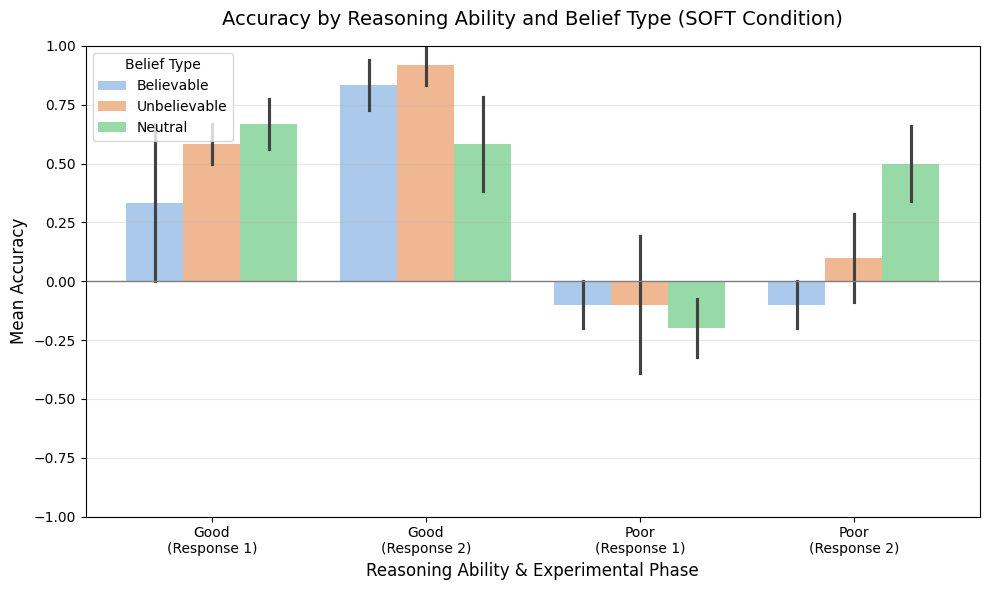

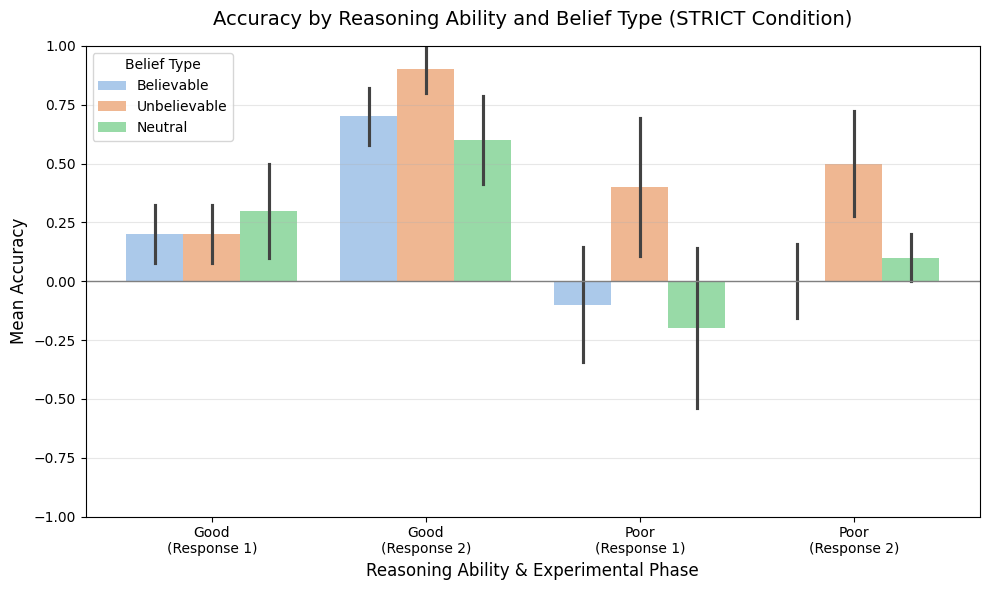

In [49]:
# Generate the plots separately for each condition
cols_to_compare = {'Response 1': 'logic_index_1', 'Response 2': 'logic_index_2'}

for cond in logic_indexes_summary['assigned_condition'].unique():
    cond_df = logic_indexes_summary[logic_indexes_summary['assigned_condition'] == cond]
    plot_bars_reasoning_ability(
        cond_df,
        cols_to_compare,
        f"Accuracy by Reasoning Ability and Belief Type ({cond.upper()} Condition)",
        "Mean Accuracy"
    )

In [50]:
# Aggregate logic index overall per participant to compare the two groups directly
overall_li = df_trials.groupby(['participant_code', 'assigned_condition']).apply(
    lambda x: calc_logic_index(x, 'accept_phase2')
).reset_index(name='overall_logic_index_2')

strict_li = overall_li[overall_li['assigned_condition'] == 'strict']['overall_logic_index_2']
soft_li = overall_li[overall_li['assigned_condition'] == 'soft']['overall_logic_index_2']

t_stat, p_val = stats.ttest_ind(strict_li, soft_li, equal_var=False)

print("--- INDEPENDENT LOGIC INDEX T-TEST BETWEEN CONDITIONS (PHASE 2) ---")
print(f"Strict Mean Logic Index: {strict_li.mean():.3f} (N={len(strict_li)})")
print(f"Soft Mean Logic Index:   {soft_li.mean():.3f} (N={len(soft_li)})")
print(f"Independent t-test results: t = {t_stat:.3f}, p = {p_val:.4f}\n")

--- INDEPENDENT LOGIC INDEX T-TEST BETWEEN CONDITIONS (PHASE 2) ---
Strict Mean Logic Index: 0.443 (N=10)
Soft Mean Logic Index:   0.500 (N=11)
Independent t-test results: t = -0.373, p = 0.7137



The logic index was not significantly different between the soft and strict conditions, suggesting that the time pressure did not affect participants' overall reasoning accuracy.

In [54]:
# ============================================================
# RESPONSE ACCURACY ANOVA
# Paper design: 3 Belief x 2 Response Opportunity x 2 Reasoning Ability
# Run separately for soft and strict conditions
# ============================================================

value_vars = {'Response 1': 'logic_index_1', 'Response 2': 'logic_index_2'}

df_anova_long = pd.melt(
    logic_indexes_summary,
    id_vars=['participant_code', 'assigned_condition', 'reasoner_type', 'belief_type'],
    value_vars=list(value_vars.values()),
    var_name='Response_Opportunity',
    value_name='Accuracy'
)

df_anova_long['Response_Opportunity'] = df_anova_long['Response_Opportunity'].map(
    {v: k for k, v in value_vars.items()}
)

# Sanity check before ANOVA
print("Participant count by condition and reasoner type:")
display(
    df_anova_long.groupby(['assigned_condition', 'reasoner_type'])['participant_code']
    .nunique()
    .reset_index(name='n_participants')
)

for cond in df_anova_long['assigned_condition'].unique():
    cond_df = df_anova_long[df_anova_long['assigned_condition'] == cond].copy()

    print(f"==========================================================================")
    print(f"--- RESPONSE ACCURACY ANOVA FOR CONDITION: {cond.upper()} ---")
    print(f"Design: 3 Belief x 2 Response Opportunity x 2 Reasoning Ability")
    print(f"==========================================================================")

    formula = 'Accuracy ~ C(belief_type) * C(Response_Opportunity) * C(reasoner_type)'
    model = ols(formula, data=cond_df).fit()

    anova_results = sm.stats.anova_lm(model, typ=2)

    display(anova_results.round(4))
    print("\n")

Participant count by condition and reasoner type:


,assigned_condition,reasoner_type,n_participants
0,soft,Good,6
1,soft,Poor,5
2,strict,Good,5
3,strict,Poor,5


--- RESPONSE ACCURACY ANOVA FOR CONDITION: SOFT ---
Design: 3 Belief x 2 Response Opportunity x 2 Reasoning Ability


,sum_sq,df,F,PR(>F)
C(belief_type),0.2727,2.0,0.7982,0.4554
C(Response_Opportunity),1.2273,1.0,7.1840,0.0097
C(reasoner_type),6.6213,1.0,38.7591,0.0000
C(belief_type):C(Response_Opportunity),0.0000,2.0,0.0000,1.0000
C(belief_type):C(reasoner_type),0.2245,2.0,0.6571,0.5225
C(Response_Opportunity):C(reasoner_type),0.0102,1.0,0.0599,0.8076
C(belief_type):C(Response_Opportunity):C(reasoner_type),1.1917,2.0,3.4878,0.0376
Residual,9.2250,54.0,NaN,NaN




--- RESPONSE ACCURACY ANOVA FOR CONDITION: STRICT ---
Design: 3 Belief x 2 Response Opportunity x 2 Reasoning Ability


,sum_sq,df,F,PR(>F)
C(belief_type),1.2000,2.0,3.0316,0.0576
C(Response_Opportunity),1.6667,1.0,8.4211,0.0056
C(reasoner_type),2.0167,1.0,10.1895,0.0025
C(belief_type):C(Response_Opportunity),0.0333,2.0,0.0842,0.9194
C(belief_type):C(reasoner_type),0.5333,2.0,1.3474,0.2696
C(Response_Opportunity):C(reasoner_type),0.4167,1.0,2.1053,0.1533
C(belief_type):C(Response_Opportunity):C(reasoner_type),0.2333,2.0,0.5895,0.5586
Residual,9.5000,48.0,NaN,NaN


In [55]:
# ============================================================
# ONE-SAMPLE T-TESTS AGAINST CHANCE
# Chance performance = logic index of 0
# Use participant-level overall logic index
# ============================================================

for cond in reasoner_split['assigned_condition'].unique():
    cond_df = reasoner_split[reasoner_split['assigned_condition'] == cond]

    print(f"--------------------------------------------------------------------------")
    print(f"--- ACCURACY ONE-SAMPLE T-TEST AGAINST CHANCE (0) FOR CONDITION: {cond.upper()} ---")
    print(f"--------------------------------------------------------------------------")

    for r_type in ['Good', 'Poor']:
        accuracy_scores = cond_df[cond_df['reasoner_type'] == r_type]['overall_logic_index'].dropna()
        t_stat, p_val = stats.ttest_1samp(accuracy_scores, 0)

        print(
            f"Reasoner Type: {r_type:<4} | "
            f"M = {accuracy_scores.mean():.3f}, "
            f"t({len(accuracy_scores)-1}) = {t_stat:.3f}, "
            f"p = {p_val:.4f}, "
            f"N = {len(accuracy_scores)}"
        )
    print("\n")

--------------------------------------------------------------------------
--- ACCURACY ONE-SAMPLE T-TEST AGAINST CHANCE (0) FOR CONDITION: SOFT ---
--------------------------------------------------------------------------
Reasoner Type: Good | M = 0.653, t(5) = 7.069, p = 0.0009, N = 6
Reasoner Type: Poor | M = 0.017, t(4) = 0.343, p = 0.7489, N = 5


--------------------------------------------------------------------------
--- ACCURACY ONE-SAMPLE T-TEST AGAINST CHANCE (0) FOR CONDITION: STRICT ---
--------------------------------------------------------------------------
Reasoner Type: Good | M = 0.473, t(4) = 8.473, p = 0.0011, N = 5
Reasoner Type: Poor | M = 0.108, t(4) = 1.534, p = 0.1998, N = 5




In [56]:
# ============================================================
# FOLLOW-UP TESTS: BELIEF EFFECT ON RESPONSE ACCURACY
# Article follow-up:
# Unbelievable vs Believable
# Unbelievable vs Neutral
# Believable vs Neutral
# Collapsed across response opportunity and reasoning ability
# ============================================================

belief_accuracy = (
    df_anova_long
    .groupby(['assigned_condition', 'participant_code', 'belief_type'])['Accuracy']
    .mean()
    .reset_index()
)

def paired_belief_test(data, belief_a, belief_b):
    wide = data.pivot_table(
        index='participant_code',
        columns='belief_type',
        values='Accuracy'
    )

    paired = wide[[belief_a, belief_b]].dropna()

    t_stat, p_val = stats.ttest_rel(paired[belief_a], paired[belief_b])

    print(
        f"{belief_a} vs {belief_b}: "
        f"{belief_a} M = {paired[belief_a].mean():.3f}, "
        f"{belief_b} M = {paired[belief_b].mean():.3f}, "
        f"t({len(paired)-1}) = {t_stat:.3f}, p = {p_val:.4f}"
    )

for cond in belief_accuracy['assigned_condition'].unique():
    print("\n")
    print("--------------------------------------------------------------------------")
    print(f"--- BELIEF FOLLOW-UP TESTS FOR CONDITION: {cond.upper()} ---")
    print("--------------------------------------------------------------------------")

    cond_data = belief_accuracy[belief_accuracy['assigned_condition'] == cond]

    paired_belief_test(cond_data, 'Unbelievable', 'Believable')
    paired_belief_test(cond_data, 'Unbelievable', 'Neutral')
    paired_belief_test(cond_data, 'Believable', 'Neutral')



--------------------------------------------------------------------------
--- BELIEF FOLLOW-UP TESTS FOR CONDITION: SOFT ---
--------------------------------------------------------------------------
Unbelievable vs Believable: Unbelievable M = 0.409, Believable M = 0.273, t(10) = 1.399, p = 0.1921
Unbelievable vs Neutral: Unbelievable M = 0.409, Neutral M = 0.409, t(10) = 0.000, p = 1.0000
Believable vs Neutral: Believable M = 0.273, Neutral M = 0.409, t(10) = -1.491, p = 0.1669


--------------------------------------------------------------------------
--- BELIEF FOLLOW-UP TESTS FOR CONDITION: STRICT ---
--------------------------------------------------------------------------
Unbelievable vs Believable: Unbelievable M = 0.500, Believable M = 0.200, t(9) = 1.964, p = 0.0811
Unbelievable vs Neutral: Unbelievable M = 0.500, Neutral M = 0.200, t(9) = 1.650, p = 0.1333
Believable vs Neutral: Believable M = 0.200, Neutral M = 0.200, t(9) = 0.000, p = 1.0000


In [58]:
# ============================================================
# FOLLOW-UP TESTS: BELIEF x REASONING ABILITY INTERACTION
# Same belief comparisons as above,
# but separately for Good and Poor reasoners
# ============================================================

belief_accuracy_by_reasoner = (
    df_anova_long
    .groupby(['assigned_condition', 'reasoner_type', 'participant_code', 'belief_type'])['Accuracy']
    .mean()
    .reset_index()
)

def paired_belief_test_by_reasoner(data, belief_a, belief_b):
    wide = data.pivot_table(
        index='participant_code',
        columns='belief_type',
        values='Accuracy'
    )

    paired = wide[[belief_a, belief_b]].dropna()

    if len(paired) < 2:
        print(f"{belief_a} vs {belief_b}: Not enough paired observations")
        return

    t_stat, p_val = stats.ttest_rel(paired[belief_a], paired[belief_b])

    print(
        f"{belief_a} vs {belief_b}: "
        f"{belief_a} M = {paired[belief_a].mean():.3f}, "
        f"{belief_b} M = {paired[belief_b].mean():.3f}, "
        f"t({len(paired)-1}) = {t_stat:.3f}, p = {p_val:.4f}, "
        f"N = {len(paired)}"
    )

for cond in belief_accuracy_by_reasoner['assigned_condition'].unique():
    for r_type in ['Good', 'Poor']:
        print("\n")
        print("--------------------------------------------------------------------------")
        print(f"--- BELIEF x REASONING ABILITY FOLLOW-UPS | {r_type.upper()} REASONERS | CONDITION: {cond.upper()} ---")
        print("--------------------------------------------------------------------------")

        cond_reasoner_data = belief_accuracy_by_reasoner[
            (belief_accuracy_by_reasoner['assigned_condition'] == cond) &
            (belief_accuracy_by_reasoner['reasoner_type'] == r_type)
        ]

        paired_belief_test_by_reasoner(cond_reasoner_data, 'Unbelievable', 'Believable')
        paired_belief_test_by_reasoner(cond_reasoner_data, 'Unbelievable', 'Neutral')
        paired_belief_test_by_reasoner(cond_reasoner_data, 'Believable', 'Neutral')



--------------------------------------------------------------------------
--- BELIEF x REASONING ABILITY FOLLOW-UPS | GOOD REASONERS | CONDITION: SOFT ---
--------------------------------------------------------------------------
Unbelievable vs Believable: Unbelievable M = 0.750, Believable M = 0.583, t(5) = 1.195, p = 0.2856, N = 6
Unbelievable vs Neutral: Unbelievable M = 0.750, Neutral M = 0.625, t(5) = 1.168, p = 0.2956, N = 6
Believable vs Neutral: Believable M = 0.583, Neutral M = 0.625, t(5) = -0.277, p = 0.7926, N = 6


--------------------------------------------------------------------------
--- BELIEF x REASONING ABILITY FOLLOW-UPS | POOR REASONERS | CONDITION: SOFT ---
--------------------------------------------------------------------------
Unbelievable vs Believable: Unbelievable M = 0.000, Believable M = -0.100, t(4) = 0.667, p = 0.5415, N = 5
Unbelievable vs Neutral: Unbelievable M = 0.000, Neutral M = 0.150, t(4) = -0.885, p = 0.4263, N = 5
Believable vs Neutral: 

In [60]:
# ============================================================
# FOLLOW-UP TESTS: RESPONSE OPPORTUNITY EFFECT ON ACCURACY
# Article follow-up:
# 1. Response 2 vs Response 1
# 2. Accuracy increase by belief type
# ============================================================

# ------------------------------------------------------------
# 1. Overall Response 2 vs Response 1
# Collapsed across belief type and reasoning ability
# ------------------------------------------------------------

response_accuracy = (
    df_anova_long
    .groupby(['assigned_condition', 'participant_code', 'Response_Opportunity'])['Accuracy']
    .mean()
    .reset_index()
)

for cond in response_accuracy['assigned_condition'].unique():
    print("\n")
    print("--------------------------------------------------------------------------")
    print(f"--- RESPONSE OPPORTUNITY FOLLOW-UP FOR CONDITION: {cond.upper()} ---")
    print("--------------------------------------------------------------------------")

    cond_data = response_accuracy[response_accuracy['assigned_condition'] == cond]

    wide = cond_data.pivot_table(
        index='participant_code',
        columns='Response_Opportunity',
        values='Accuracy'
    )

    paired = wide[['Response 1', 'Response 2']].dropna()

    t_stat, p_val = stats.ttest_rel(paired['Response 2'], paired['Response 1'])

    print(
        f"Response 2 vs Response 1: "
        f"Response 1 M = {paired['Response 1'].mean():.3f}, "
        f"Response 2 M = {paired['Response 2'].mean():.3f}, "
        f"Mean increase = {(paired['Response 2'] - paired['Response 1']).mean():.3f}, "
        f"t({len(paired)-1}) = {t_stat:.3f}, p = {p_val:.4f}, "
        f"N = {len(paired)}"
    )


# ------------------------------------------------------------
# 2. Accuracy increase by belief type
# This checks the Response Opportunity x Belief interaction
# ------------------------------------------------------------

accuracy_increase_by_belief = (
    df_anova_long
    .pivot_table(
        index=['assigned_condition', 'participant_code', 'belief_type'],
        columns='Response_Opportunity',
        values='Accuracy'
    )
    .reset_index()
)

accuracy_increase_by_belief['accuracy_increase'] = (
    accuracy_increase_by_belief['Response 2'] -
    accuracy_increase_by_belief['Response 1']
)

def paired_increase_test(data, belief_a, belief_b):
    wide = data.pivot_table(
        index='participant_code',
        columns='belief_type',
        values='accuracy_increase'
    )

    paired = wide[[belief_a, belief_b]].dropna()

    if len(paired) < 2:
        print(f"{belief_a} vs {belief_b}: Not enough paired observations")
        return

    t_stat, p_val = stats.ttest_rel(paired[belief_a], paired[belief_b])

    print(
        f"Increase {belief_a} vs {belief_b}: "
        f"{belief_a} M increase = {paired[belief_a].mean():.3f}, "
        f"{belief_b} M increase = {paired[belief_b].mean():.3f}, "
        f"t({len(paired)-1}) = {t_stat:.3f}, p = {p_val:.4f}, "
        f"N = {len(paired)}"
    )

for cond in accuracy_increase_by_belief['assigned_condition'].unique():
    print("\n")
    print("--------------------------------------------------------------------------")
    print(f"--- ACCURACY INCREASE BY BELIEF TYPE FOR CONDITION: {cond.upper()} ---")
    print("--------------------------------------------------------------------------")

    cond_data = accuracy_increase_by_belief[
        accuracy_increase_by_belief['assigned_condition'] == cond
    ]

    paired_increase_test(cond_data, 'Unbelievable', 'Believable')
    paired_increase_test(cond_data, 'Unbelievable', 'Neutral')
    paired_increase_test(cond_data, 'Believable', 'Neutral')



--------------------------------------------------------------------------
--- RESPONSE OPPORTUNITY FOLLOW-UP FOR CONDITION: SOFT ---
--------------------------------------------------------------------------
Response 2 vs Response 1: Response 1 M = 0.227, Response 2 M = 0.500, Mean increase = 0.273, t(10) = 2.243, p = 0.0488, N = 11


--------------------------------------------------------------------------
--- RESPONSE OPPORTUNITY FOLLOW-UP FOR CONDITION: STRICT ---
--------------------------------------------------------------------------
Response 2 vs Response 1: Response 1 M = 0.133, Response 2 M = 0.467, Mean increase = 0.333, t(9) = 3.586, p = 0.0059, N = 10


--------------------------------------------------------------------------
--- ACCURACY INCREASE BY BELIEF TYPE FOR CONDITION: SOFT ---
--------------------------------------------------------------------------
Increase Unbelievable vs Believable: Unbelievable M increase = 0.273, Believable M increase = 0.273, t(10) = 0

### Response Accuracy - Interim Summary

Following the original article, response accuracy was operationalized using a logic index: the proportion of accepted valid conclusions minus the proportion of accepted invalid conclusions. Participants were divided into Good and Poor reasoners using a participant-level median split on overall logic index.

The response accuracy analyses reconstructed the article's main approach: a 3 Belief x 2 Response Opportunity x 2 Reasoning Ability ANOVA, followed by tests against chance, belief-condition comparisons, belief comparisons within reasoning ability groups, and response-opportunity comparisons.

In our data, Good reasoners performed above chance in both conditions, whereas Poor reasoners did not. Accuracy increased from Response 1 to Response 2 in both conditions. However, unlike the original Experiment 1 pattern, the increase in accuracy did not differ meaningfully by belief type in our data.

In [61]:
# ============================================================
# BETWEEN-CONDITION ACCURACY COMPARISON
# Supplementary analysis: strict vs soft on participant-level overall logic index
# ============================================================

print(f"--------------------------------------------------------------------------")
print(f"--- INDEPENDENT ACCURACY T-TEST BETWEEN CONDITIONS ---")
print(f"--------------------------------------------------------------------------")

strict_acc = reasoner_split[reasoner_split['assigned_condition'] == 'strict']['overall_logic_index']
soft_acc = reasoner_split[reasoner_split['assigned_condition'] == 'soft']['overall_logic_index']

t_between, p_between = stats.ttest_ind(strict_acc, soft_acc, equal_var=False)

print(f"Strict Overall Mean Accuracy: {strict_acc.mean():.3f} (N={len(strict_acc)})")
print(f"Soft Overall Mean Accuracy:   {soft_acc.mean():.3f} (N={len(soft_acc)})")
print(f"Independent t-test results: t = {t_between:.3f}, p = {p_between:.4f}\n")

--------------------------------------------------------------------------
--- INDEPENDENT ACCURACY T-TEST BETWEEN CONDITIONS ---
--------------------------------------------------------------------------
Strict Overall Mean Accuracy: 0.291 (N=10)
Soft Overall Mean Accuracy:   0.364 (N=11)
Independent t-test results: t = -0.538, p = 0.5973



### Self-Reported Confidence